In [52]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from models import carl, rolypoly
from physics.simulation import mcfm, msq
from physics.hzz import zz4l, zpair
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [53]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

CARL_JOB = 'qqZZ-vs-SBI-01'
CARL_CKPT = [119,0.68]
ROLYPOLY_JOB = 'refactor-eight-SBI-3M'
ROLYPOLY_CKPT = [[178,0.05],['06',0.15],[83,0.01],[187,0.03]]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'
SAMPLE_FILE_qqZZ = 'qqZZ2e2m.csv'

CARL_PATH = os.path.join(JOB_DIR, 'carl', CARL_JOB)
CARL_CKPT_PATH = os.path.join(CARL_PATH, 'checkpoints', f'checkpoint-carl-epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
ROLYPOLY_PATH = os.path.join(JOB_DIR, 'rolypoly', ROLYPOLY_JOB)
ROLYPOLY_CKPT_PATHs = [os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-rolypoly-epoch={ROLYPOLY_CKPT[i][0]}-val_loss={ROLYPOLY_CKPT[i][1]}.ckpt') for i in range(len(ROLYPOLY_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
SAMPLE_PATH_qqZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_qqZZ)

In [54]:
SAMPLE_SIZE = 100000

luminosity = 3000

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 512

C6_LINSPACE = [-20,20,101]

C6_VAL_DATA = 10

SEED = 42

In [55]:
xs = {'ggZZ': 1.5569109, 'qqZZ': 14.482054}

In [56]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_qqZZ, n_rows=SAMPLE_SIZE*1.2)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

events_processed = mcfm.Process(pd.concat([events_ggZZ_processed.kinematics, events_qqZZ_processed.kinematics]).reset_index(drop=True),
                                pd.concat([events_ggZZ_processed.components, events_qqZZ_processed.components]).reset_index(drop=True),
                                pd.concat([events_ggZZ_processed.weights, events_qqZZ_processed.weights]).reset_index(drop=True))

0.6458769410846456
6.252942726855464


In [57]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
c6_weights, c6_prob = c6_mod.modify(c6=C6_VAL_DATA)

In [58]:
events_final = mcfm.Process(events_ggZZ_processed.kinematics.reset_index(drop=True)[:SAMPLE_SIZE],
                            events_ggZZ_processed.components.reset_index(drop=True)[:SAMPLE_SIZE],
                            pd.Series(c6_weights.flatten()).reset_index(drop=True)[:SAMPLE_SIZE]*np.sum(c6_weights)/np.sum(c6_weights[:SAMPLE_SIZE]))
                        #   Fixing the cross section to remain the same after cutting events to SAMPLE_SIZE

In [59]:
sigma_ggZZ_data = events_final.weights.sum()

In [60]:
kinematics = events_final.kinematics[FEATURES]

In [61]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)

In [62]:
models_rolypoly = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=path) for path in ROLYPOLY_CKPT_PATHs]

In [63]:
with open(os.path.join(CARL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)

X_carl = scaler_carl.transform(kinematics.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [64]:
trainer = L.Trainer(accelerator='cpu')

pred_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0:   2%|▏         | 4/196 [00:00<00:20,  9.43it/s]

Predicting DataLoader 0: 100%|██████████| 196/196 [00:20<00:00,  9.45it/s]


In [65]:
r = pred_carl/(1-pred_carl)

In [66]:
dls_rolypoly = []
for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_rolypoly = scaler_X.transform(kinematics.to_numpy())
    dl = DataLoader(TensorDataset(torch.tensor(X_rolypoly, dtype=torch.float32)), batch_size=BATCH_SIZE)
    dls_rolypoly.append(dl)

In [67]:
coeffs_pred = []

for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_rolypoly[i], dls_rolypoly[i])).numpy()[:,np.newaxis]).flatten())

coeffs_pred = np.array(coeffs_pred).T

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0:   5%|▌         | 10/196 [00:01<00:19,  9.49it/s]

Predicting DataLoader 0: 100%|██████████| 196/196 [00:20<00:00,  9.51it/s]

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Predicting DataLoader 0: 100%|██████████| 196/196 [00:21<00:00,  9.33it/s]

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Predicting DataLoader 0: 100%|██████████| 196/196 [00:20<00:00,  9.44it/s]

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Predicting DataLoader 0: 100%|██████████| 196/196 [00:20<00:00,  9.52it/s]


In [68]:
def f(c6_values, coeffs):
    return np.array([np.apply_along_axis(lambda x: np.polyval(x, c6_value), 1, np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)[:, ::-1]) for c6_value in c6_values])

In [69]:
c6_values = np.linspace(*C6_LINSPACE)

In [70]:
bsm_weights = c6_mod.modify(c6=c6_values)[0]
sigma_ggZZ_BSM = np.sum(bsm_weights, axis=0)

In [71]:
full_SM_xs = sigma_ggZZ #+ sigma_qqZZ

full_BSM_xs = sigma_ggZZ_BSM #+ sigma_qqZZ 

nu_SM = full_SM_xs * luminosity
nu = full_BSM_xs * luminosity

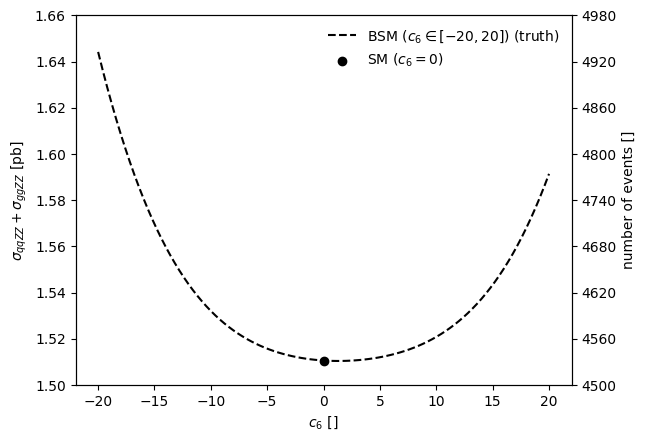

In [72]:
plt.plot(c6_values, full_BSM_xs, color='black', linestyle='--', zorder=1, label='BSM ($c_6 \in [-20,20]$) (truth)')
#plt.plot(c6_values, sigma_ggZZ*sum_f_over_N, color='royalblue', zorder=1, label='BSM ($c_6 \in [-20,20]$) (ROLYPOLY)')
plt.scatter(0, full_SM_xs, color='k', marker='o', zorder=2, label='SM ($c_6=0$)')

ax1 = plt.gca()
ax1.set_ylim(ax1.get_yticks()[0],ax1.get_yticks()[-1])
ax1.set_ylabel('$\sigma_{qqZZ} + \sigma_{ggZZ}$ [pb]')

ax2 = ax1.twinx()

y_ticks_number = np.array(ax1.get_yticks())*3000

ax2.set_yticks(y_ticks_number)
ax2.set_ylim(y_ticks_number[0], y_ticks_number[-1])
ax2.set_ylabel('number of events []')

ax1.legend(frameon=False)
ax1.set_xlabel('$c_6$ []')

plt.show()

In [73]:
print(f'XS minimum at c6={c6_values[np.argmin(sigma_ggZZ_BSM)]:0.2f}')

XS minimum at c6=1.20


In [74]:
N_data = sigma_ggZZ_data*luminosity

t_1 = - 2 * N_data * (np.log(nu) - np.log(nu_SM)) + 2 * (nu - nu_SM) 

In [75]:
t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(sigma_ggZZ/sigma_ggZZ_BSM[:,np.newaxis] * f(c6_values, c6_mod.coefficients[:SAMPLE_SIZE,1:])), axis=1)

In [76]:
#t_3_1 = - 2*SAMPLE_SIZE*np.log(1 + sigma_qqZZ/sigma_ggZZ) + 2*SAMPLE_SIZE*np.log(sigma_ggZZ_BSM/sigma_ggZZ + sigma_qqZZ/sigma_ggZZ)

In [77]:
#t_3_2 = -2*np.sum(np.log((f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)/(1 + sigma_qqZZ/sigma_ggZZ * r)), axis=1)

In [78]:
#t_3 = t_3_1 + t_3_2

In [79]:
t = t_2

In [80]:
t_min = c6_values[np.argmin(t)]

In [81]:
print(c6_values[np.argsort(t)[:10]])

[ 9.6  9.2 10.   8.8 10.4  8.4 10.8  8.   7.6 11.2]


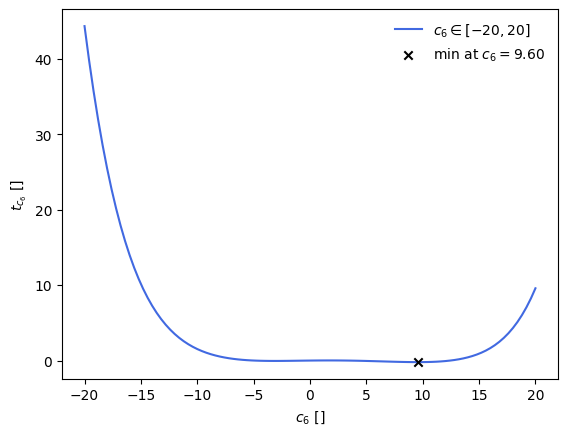

In [82]:
plt.plot(c6_values, t, color='royalblue', zorder=1, label='$c_6 \in [-20,20]$')
plt.scatter(t_min, np.min(t), marker='x', color='k', label=f'min at $c_6 = {t_min:0.2f}$')


plt.ylabel('$t_{c_6}$ []')

plt.legend(frameon=False)
plt.xlabel('$c_6$ []')


plt.show()

In [83]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))

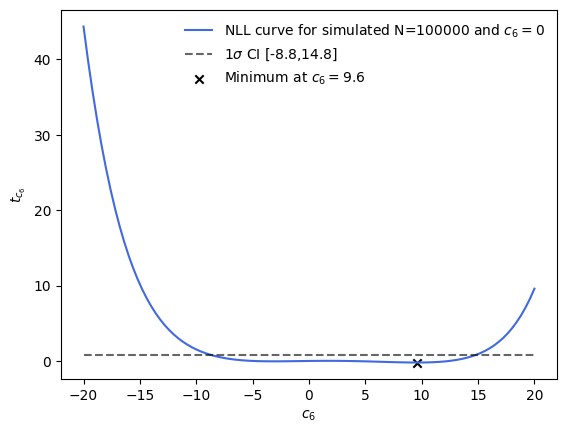

In [84]:
plt.plot(c6_values, t, color='royalblue', label=f'NLL curve for simulated N={SAMPLE_SIZE} and $c_6 = 0$')
plt.hlines(np.min(t)+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$1\sigma$ CI [{ci[0]},{ci[1]}]')
plt.scatter(t_min, np.min(t), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

plt.xlabel('$c_6$')
plt.ylabel('$t_{c_6}$')

plt.legend(frameon=False)
plt.show()